In [1]:
import os
from pathlib import Path

import pandas as pd

# Carregando as tabelas que vao fazer parte do modelo

## Dados das Armardilhas - Ago2025 em diante (raspagem)

In [2]:
# Acha a raiz do projeto (Meu_Projeto/) subindo a partir do diretório atual
# até encontrar a pasta 'Raspagem' (evita caminho absoluto hard-coded).
def achar_raiz(marcador="Raspagem"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marcador).is_dir():
            return p
    raise FileNotFoundError(f"Pasta-raiz contendo '{marcador}/' nao encontrada a partir de {Path.cwd()}")


RAIZ = achar_raiz()
BASE_ARMADILHAS = RAIZ / "Bases de dados" / "juntar_arquivos_raspagem" / "output" / "base_armadilhas_concatenada.csv"

df_raspagem = pd.read_csv(BASE_ARMADILHAS, parse_dates=["data_coleta"])

print("arquivo:", BASE_ARMADILHAS.name)
print("linhas x colunas:", df_raspagem.shape)
print("semanas (week_id):", df_raspagem["week_id"].nunique())
print("período:", df_raspagem["data_coleta"].min().date(), "->", df_raspagem["data_coleta"].max().date())

arquivo: base_armadilhas_concatenada.csv
linhas x colunas: (39130, 25)
semanas (week_id): 43
período: 2025-08-16 -> 2026-06-12


In [3]:
df_raspagem.dtypes.to_frame("tipo")

,tipo
id,int64
week_id,int64
trap_id,int64
agent_id,int64
week,str
agent,str
status,str
status_id,float64
inspection_id,float64
aedes_aegypti_femea,int64


In [4]:
#forçar aparecer todas as colunas no df
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
df_raspagem.head(2)

,id,week_id,trap_id,agent_id,week,agent,status,status_id,inspection_id,aedes_aegypti_femea,aedes_aegypti_macho,aedes_albopictus_femea,aedes_albopictus_macho,culex_sp_femea,culex_sp_macho,total_mosquitos,latitude,longitude,street,number,block,complement,neighborhood,arquivo_origem,data_coleta
0,4299153,450,11096,1065,33/2025,Lucas Bonesso,Realizada,10.0,1885818.0,0,0,0,0,0,0,0,-30.069557,-51.184382,AV SILVADO,456,NaN,ESCOLA TIO CHICO,APARICIO BORGES,dados_aedes_20250816_weekid450_62mosquitos.xlsx,2025-08-16
1,4299154,450,11097,1065,33/2025,Lucas Bonesso,Realizada,10.0,1885884.0,0,0,0,0,0,0,0,-30.068380,-51.180694,AV VEIGA,633,2237369.0,Cond. Jardim Partenon,APARICIO BORGES,dados_aedes_20250816_weekid450_62mosquitos.xlsx,2025-08-16


## Dados das armadilhas - 2019 até 2023 (marilia)

In [5]:
BASE_MARILIA = RAIZ / "Bases de dados" / "dados_marilia" / "output" / "base_dados_marilia.csv"

df_marilia = pd.read_csv(BASE_MARILIA, parse_dates=["Data Inicio", "Data Fim"])

print("arquivo:", BASE_MARILIA.name)
print("linhas x colunas:", df_marilia.shape)
print("anos:", sorted(df_marilia["Ano"].unique().tolist()))
print("período:", df_marilia["Data Inicio"].min().date(), "->", df_marilia["Data Fim"].max().date())

arquivo: base_dados_marilia.csv
linhas x colunas: (235755, 16)
anos: [2019, 2020, 2021, 2022, 2023]
período: 2018-12-30 -> 2023-06-10


/var/folders/y1/kgy7lprs7jvbr9fc59xjs9ch0000gn/T/ipykernel_33783/3785666811.py:3: DtypeWarning: Columns (0: Latitude, 1: Longitude) have mixed types. Specify dtype option on import or set low_memory=False.
  df_marilia = pd.read_csv(BASE_MARILIA, parse_dates=["Data Inicio", "Data Fim"])


In [6]:
df_marilia.dtypes.to_frame("tipo")

,tipo
ID,int64
Local,str
Ano,int64
Semana,int64
Data Inicio,datetime64[us]
Data Fim,datetime64[us]
Latitude,object
Longitude,object
Aedes aegypti,int64
Aedes albopictus,int64


In [7]:
df_marilia.head()

,ID,Local,Ano,Semana,Data Inicio,Data Fim,Latitude,Longitude,Aedes aegypti,Aedes albopictus,Culex sp,Precipitation,Temperature,Relative humidity,Mes,arquivo_origem
0,470960,CAVALHADA,2019,1,2018-12-30,2019-01-05,-30.103,-51.247,0,0,0,NaN,NaN,NaN,12,saida_2019.csv
1,470961,CAVALHADA,2019,1,2018-12-30,2019-01-05,-30.103,-51.25,0,0,1,NaN,NaN,NaN,12,saida_2019.csv
2,470962,CAVALHADA,2019,1,2018-12-30,2019-01-05,-30.105,-51.512,0,0,1,NaN,NaN,NaN,12,saida_2019.csv
3,470963,CAVALHADA,2019,1,2018-12-30,2019-01-05,-30.105,-51.25,0,0,0,NaN,NaN,NaN,12,saida_2019.csv
4,470964,CAMAQUÃ,2019,1,2018-12-30,2019-01-05,-30.103,-51.255,0,0,0,NaN,NaN,NaN,12,saida_2019.csv


## Concatenando os dados das armadilhas

### Juntando os dados da raspagem com a marilia

In [8]:
# Marília no formato unificado (espécies já agregadas; lat/long coagidos p/ número —
# vírgula decimal de 2021/22 e 5 valores corrompidos de 2022 viram NaN).
marilia_u = pd.DataFrame({
    "fonte": "marilia",
    "SE": df_marilia["Ano"] * 100 + df_marilia["Semana"],
    "data_inicio_semana_epidemi": df_marilia["Data Inicio"],
    "ano": df_marilia["Ano"],
    "semana": df_marilia["Semana"],
    "id_inspecao": df_marilia["ID"],
    "local": df_marilia["Local"],
    "latitude": pd.to_numeric(df_marilia["Latitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"),
    "longitude": pd.to_numeric(df_marilia["Longitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"),
    "aedes_aegypti": df_marilia["Aedes aegypti"],
    "aedes_albopictus": df_marilia["Aedes albopictus"],
    "culex_sp": df_marilia["Culex sp"],
    "arquivo_origem": df_marilia["arquivo_origem"],
})
print("marilia_u:", marilia_u.shape)
marilia_u.head(2)

marilia_u: (235755, 13)


,fonte,SE,data_inicio_semana_epidemi,ano,semana,id_inspecao,local,latitude,longitude,aedes_aegypti,aedes_albopictus,culex_sp,arquivo_origem
0,marilia,201901,2018-12-30,2019,1,470960,CAVALHADA,-30.103,-51.247,0,0,0,saida_2019.csv
1,marilia,201901,2018-12-30,2019,1,470961,CAVALHADA,-30.103,-51.250,0,0,1,saida_2019.csv


In [9]:
# Raspagem no formato unificado: soma fêmea+macho por espécie; SE vem de `week` (SS/AAAA);
# data_inicio_semana_epidemi = domingo (início da SE) derivado de data_coleta.
_wk = df_raspagem["week"].str.split("/", expand=True)
_semana = _wk[0].astype(int)
_ano = _wk[1].astype(int)
_domingo = df_raspagem["data_coleta"] - pd.to_timedelta((df_raspagem["data_coleta"].dt.weekday + 1) % 7, unit="D")

raspagem_u = pd.DataFrame({
    "fonte": "raspagem",
    "SE": _ano * 100 + _semana,
    "data_inicio_semana_epidemi": _domingo,
    "ano": _ano,
    "semana": _semana,
    "id_inspecao": df_raspagem["id"],
    "local": df_raspagem["neighborhood"],
    "latitude": df_raspagem["latitude"],
    "longitude": df_raspagem["longitude"],
    "aedes_aegypti": df_raspagem["aedes_aegypti_femea"] + df_raspagem["aedes_aegypti_macho"],
    "aedes_albopictus": df_raspagem["aedes_albopictus_femea"] + df_raspagem["aedes_albopictus_macho"],
    "culex_sp": df_raspagem["culex_sp_femea"] + df_raspagem["culex_sp_macho"],
    "arquivo_origem": df_raspagem["arquivo_origem"],
})
print("raspagem_u:", raspagem_u.shape)
raspagem_u.head(2)

raspagem_u: (39130, 13)


,fonte,SE,data_inicio_semana_epidemi,ano,semana,id_inspecao,local,latitude,longitude,aedes_aegypti,aedes_albopictus,culex_sp,arquivo_origem
0,raspagem,202533,2025-08-10,2025,33,4299153,APARICIO BORGES,-30.069557,-51.184382,0,0,0,dados_aedes_20250816_weekid450_62mosquitos.xlsx
1,raspagem,202533,2025-08-10,2025,33,4299154,APARICIO BORGES,-30.068380,-51.180694,0,0,0,dados_aedes_20250816_weekid450_62mosquitos.xlsx


In [10]:
# Tabela única de armadilhas (Marília 2019–2023 + raspagem 2025–2026)
df_armadilhas = (
    pd.concat([marilia_u, raspagem_u], ignore_index=True)
    .sort_values(["SE", "fonte"])
    .reset_index(drop=True)
)

print("base completa:", df_armadilhas.shape)
for f in ["marilia", "raspagem"]:
    s = df_armadilhas[df_armadilhas["fonte"] == f]
    print(f"  {f}: {len(s)} linhas | SE {s['SE'].min()}-{s['SE'].max()} | "
          f"{s['data_inicio_semana_epidemi'].min().date()} -> {s['data_inicio_semana_epidemi'].max().date()}")
print("data_inicio sempre domingo?", (df_armadilhas["data_inicio_semana_epidemi"].dt.weekday == 6).all())
print("lat/long nulos:", int(df_armadilhas["latitude"].isna().sum()))
df_armadilhas.head()

base completa: (274885, 13)
  marilia: 235755 linhas | SE 201901-202323 | 2018-12-30 -> 2023-06-04
  raspagem: 39130 linhas | SE 202533-202623 | 2025-08-10 -> 2026-06-07
data_inicio sempre domingo? True
lat/long nulos: 5


,fonte,SE,data_inicio_semana_epidemi,ano,semana,id_inspecao,local,latitude,longitude,aedes_aegypti,aedes_albopictus,culex_sp,arquivo_origem
0,marilia,201901,2018-12-30,2019,1,470960,CAVALHADA,-30.103,-51.247,0,0,0,saida_2019.csv
1,marilia,201901,2018-12-30,2019,1,470961,CAVALHADA,-30.103,-51.250,0,0,1,saida_2019.csv
2,marilia,201901,2018-12-30,2019,1,470962,CAVALHADA,-30.105,-51.512,0,0,1,saida_2019.csv
3,marilia,201901,2018-12-30,2019,1,470963,CAVALHADA,-30.105,-51.250,0,0,0,saida_2019.csv
4,marilia,201901,2018-12-30,2019,1,470964,CAMAQUÃ,-30.103,-51.255,0,0,0,saida_2019.csv


### Checagem visual — Aedes aegypti capturados por semana

Soma semanal de *Ae. aegypti*, por fonte. Cada bloco é reindexado ao calendário completo de domingos, então **semana ausente quebra a linha** (diferente do zero do inverno, que aparece como ponto baixo). Mostra a sazonalidade do vetor e ainda revela furos de coleta + o gap 2023–2025.

raspagem: 1 semana(s) sem dado -> [datetime.date(2025, 10, 5)]


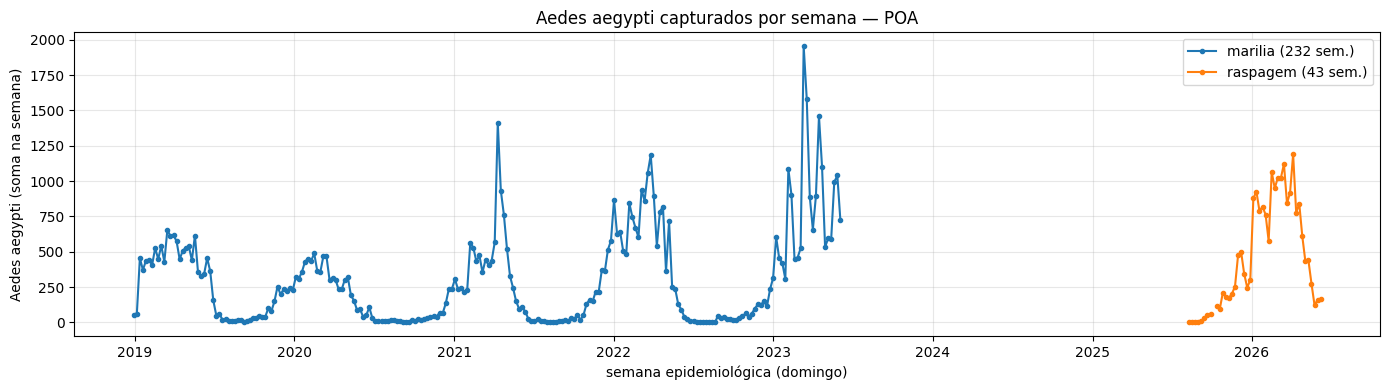

In [11]:
import matplotlib.pyplot as plt

# Aedes aegypti capturados por semana, por fonte
sem_aegypti = (df_armadilhas
               .groupby(["fonte", "data_inicio_semana_epidemi"])
               .agg(aegypti=("aedes_aegypti", "sum"))
               .reset_index())

fig, ax = plt.subplots(figsize=(14, 4))
for fonte in ["marilia", "raspagem"]:
    s = sem_aegypti[sem_aegypti["fonte"] == fonte].set_index("data_inicio_semana_epidemi")["aegypti"]
    # reindexa ao calendário completo de domingos -> semana ausente vira NaN (quebra a linha;
    # zero do inverno aparece como ponto baixo, não como buraco).
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="W-SUN"))
    ax.plot(s.index, s.values, marker=".", label=f"{fonte} ({int(s.notna().sum())} sem.)")
    faltando = s.index[s.isna()]
    if len(faltando):
        print(f"{fonte}: {len(faltando)} semana(s) sem dado ->", [d.date() for d in faltando])

ax.set_title("Aedes aegypti capturados por semana — POA")
ax.set_xlabel("semana epidemiológica (domingo)")
ax.set_ylabel("Aedes aegypti (soma na semana)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Série semanal de vetor (com interpolação)

Agrega `df_armadilhas` por semana (por fonte): `n_armadilhas`, contagens por espécie e o índice **`aegypti_por_armadilha`** (≈ IMFA — neutraliza a variação no tamanho da rede de armadilhas). A única semana faltante (05/10/2025) é **interpolada linearmente** entre as vizinhas e marcada em `interpolado=True`. O gap 2023–2025 **não** é preenchido (`limit_area="inside"`).

In [12]:
# Agrega df_armadilhas por semana (por fonte) e interpola a única semana faltante (05/10/2025).
wkly = (df_armadilhas
        .groupby(["fonte", "data_inicio_semana_epidemi"])
        .agg(SE=("SE", "first"),
             numero_de_armadilhas=("id_inspecao", "size"),
             aedes_aegypti=("aedes_aegypti", "sum"),
             aedes_albopictus=("aedes_albopictus", "sum"),
             culex_sp=("culex_sp", "sum"))
        .reset_index())

blocos = []
for fonte in ["marilia", "raspagem"]:
    s = (wkly[wkly["fonte"] == fonte]
         .set_index("data_inicio_semana_epidemi").sort_index().drop(columns="fonte"))
    # calendário completo de domingos do bloco -> semana faltante vira NaN
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="W-SUN"))
    s["fonte"] = fonte
    s["interpolado"] = s["numero_de_armadilhas"].isna()
    # interpola só buracos internos (limit_area="inside"): não extrapola bordas nem o gap entre blocos
    for c in ["SE", "numero_de_armadilhas", "aedes_aegypti", "aedes_albopictus", "culex_sp"]:
        s[c] = s[c].interpolate(method="linear", limit_area="inside")
    blocos.append(s)

vetor_semanal = pd.concat(blocos).rename_axis("data_inicio_semana_epidemi").reset_index()
vetor_semanal["SE"] = vetor_semanal["SE"].round().astype(int)
vetor_semanal["ano"] = vetor_semanal["SE"] // 100
vetor_semanal["semana"] = vetor_semanal["SE"] % 100
vetor_semanal["numero_de_armadilhas"] = vetor_semanal["numero_de_armadilhas"].round().astype(int)
for c in ["aedes_aegypti", "aedes_albopictus", "culex_sp"]:
    vetor_semanal[c] = vetor_semanal[c].round().astype(int)
vetor_semanal["aedes_aegypti_por_armadilha"] = vetor_semanal["aedes_aegypti"] / vetor_semanal["numero_de_armadilhas"]

vetor_semanal = vetor_semanal[["fonte", "SE", "data_inicio_semana_epidemi", "ano", "semana",
                               "numero_de_armadilhas", "aedes_aegypti", "aedes_albopictus", "culex_sp",
                               "aedes_aegypti_por_armadilha", "interpolado"]]

print("série semanal de vetor:", vetor_semanal.shape, "| interpoladas:", int(vetor_semanal["interpolado"].sum()))
print("por fonte:", vetor_semanal.groupby("fonte").size().to_dict())
# a semana interpolada + vizinhas
vetor_semanal[(vetor_semanal["data_inicio_semana_epidemi"] >= "2025-09-21") &
              (vetor_semanal["data_inicio_semana_epidemi"] <= "2025-10-19")]

série semanal de vetor: (276, 11) | interpoladas: 1
por fonte: {'marilia': 232, 'raspagem': 44}


,fonte,SE,data_inicio_semana_epidemi,ano,semana,numero_de_armadilhas,aedes_aegypti,aedes_albopictus,culex_sp,aedes_aegypti_por_armadilha,interpolado
238,raspagem,202539,2025-09-21,2025,39,910,49,0,144,0.053846,False
239,raspagem,202540,2025-09-28,2025,40,910,62,0,95,0.068132,False
240,raspagem,202541,2025-10-05,2025,41,910,88,2,142,0.096703,True
241,raspagem,202542,2025-10-12,2025,42,910,113,4,189,0.124176,False
242,raspagem,202543,2025-10-19,2025,43,910,92,0,111,0.101099,False


## Dados climaticos

Clima do **NASA POWER** (fonte única; reanálise por ponto, ~0 nulos, cobre o gap 2023–2025). Inclui **precipitação, ponto de orvalho, pressão, radiação e vento** — que o InfoDengue não tinha — além de temperatura e umidade, com min/média/máx por semana. Substitui o clima do InfoDengue (que era só temp/umidade e mais suavizado; comparação mostrou temp média ~idêntica, r=0,96, mas umidade divergindo, r=0,59). Chave: `data_inicio_semana_epidemi`. Gerado por `Bases de dados/clima/captura_nasa_power.py`.

In [13]:
# Clima: NASA POWER (fonte única). Tem precipitação, orvalho, pressão, radiação e vento
# (que o InfoDengue não tem), capta extremos e cobre o gap 2023-2025.
# Gerado por Bases de dados/clima/captura_nasa_power.py (rodar de novo p/ atualizar).
BASE_CLIMA = RAIZ / "Bases de dados" / "clima" / "output" / "clima_nasa_power_semanal.csv"
df_clima = pd.read_csv(BASE_CLIMA, parse_dates=["data_inicio_semana_epidemi"])

print("df_clima (NASA POWER):", df_clima.shape)
print("período:", df_clima["data_inicio_semana_epidemi"].min().date(), "->",
      df_clima["data_inicio_semana_epidemi"].max().date())
print("variáveis:", [c for c in df_clima.columns if c != "data_inicio_semana_epidemi"])
df_clima.head()

df_clima (NASA POWER): (388, 23)
período: 2018-12-30 -> 2026-05-31
variáveis: ['precip_total_mm', 'precip_max_dia_mm', 'precip_media_dia_mm', 'dias_de_chuva', 'temp_media', 'temp_min', 'temp_max', 'temp_amplitude_media', 'orvalho_min', 'orvalho_media', 'orvalho_max', 'umid_min', 'umid_media', 'umid_max', 'pressao_min', 'pressao_media', 'pressao_max', 'radiacao_min', 'radiacao_media', 'radiacao_max', 'vento_media', 'vento_max']


,data_inicio_semana_epidemi,precip_total_mm,precip_max_dia_mm,precip_media_dia_mm,dias_de_chuva,temp_media,temp_min,temp_max,temp_amplitude_media,orvalho_min,orvalho_media,orvalho_max,umid_min,umid_media,umid_max,pressao_min,pressao_media,pressao_max,radiacao_min,radiacao_media,radiacao_max,vento_media,vento_max
0,2018-12-30,20.72,13.13,2.960000,3,25.848571,18.14,35.91,9.628571,17.91,21.871429,24.47,75.56,79.912857,86.06,100.29,100.605714,100.93,9.36,20.837143,28.12,3.535714,4.96
1,2019-01-06,17.34,5.03,2.477143,5,25.617143,21.15,32.27,7.478571,21.09,22.595714,24.14,79.57,84.040000,85.84,100.04,100.678571,101.16,10.08,15.892857,28.11,3.797143,4.99
2,2019-01-13,60.59,18.80,8.655714,7,25.478571,18.63,31.31,6.652857,18.46,22.800000,24.66,82.09,85.840000,90.33,100.48,100.737143,101.01,9.35,17.654286,26.10,3.802857,6.42
3,2019-01-20,4.02,1.92,0.574286,1,24.808571,18.38,32.16,9.147143,18.95,21.428571,22.92,78.52,82.712857,85.23,100.88,100.991429,101.13,19.28,25.187143,30.15,3.791429,5.74
4,2019-01-27,27.40,12.12,3.914286,4,28.718571,21.96,36.55,10.962857,22.61,23.482857,24.37,70.12,75.467143,81.39,100.60,100.785714,100.92,13.61,23.665714,29.06,3.071429,4.27


## Dados de casos reais

In [14]:
# Casos confirmados de dengue em POA, NÍVEL CASO (gerado por bases_governo/processar_casos.ipynb).
BASE_CASOS = RAIZ / "Bases de dados" / "bases_governo" / "output" / "casos_confirmados_poa.csv"
df_casos = pd.read_csv(BASE_CASOS, low_memory=False)

print("arquivo:", BASE_CASOS.name)
print("linhas x colunas:", df_casos.shape)
sem_pri = pd.to_numeric(df_casos["SEM_PRI"], errors="coerce")
print("SEM_PRI:", int(sem_pri.min()), "->", int(sem_pri.max()))
print("por ano (NU_ANO):", pd.to_numeric(df_casos["NU_ANO"], errors="coerce").value_counts().sort_index().to_dict())
df_casos.head()

arquivo: casos_confirmados_poa.csv
linhas x colunas: (56624, 18)
SEM_PRI: 201808 -> 202617
por ano (NU_ANO): {2018: 3, 2019: 489, 2020: 38, 2021: 72, 2022: 5583, 2023: 6591, 2024: 19025, 2025: 24811, 2026: 12}


,SEM_PRI,SEM_NOT,DT_SIN_PRI,DT_NOTIFIC,NU_ANO,ID_MUNICIP,ID_MN_RESI,CLASSI_FIN,CRITERIO,EVOLUCAO,DT_OBITO,HOSPITALIZ,CS_SEXO,NU_IDADE_N,CS_GESTANT,CS_RACA,SOROTIPO,arquivo_origem
0,201815.0,201816.0,2018-04-12,2018-04-16,2018,431490,520870.0,10.0,1.0,1.0,NaN,2.0,F,4040.0,5.0,2.0,2.0,DENGBR18.csv.zip
1,201830.0,201830.0,2018-07-25,2018-07-27,2018,431490,260005.0,10.0,1.0,1.0,NaN,2.0,F,4030.0,5.0,1.0,1.0,DENGBR18.csv.zip
2,201808.0,201809.0,2018-02-21,2018-03-02,2018,431490,431490.0,10.0,1.0,1.0,NaN,2.0,M,4028.0,6.0,4.0,NaN,DENGBR18.csv.zip
3,201920.0,201922.0,2019-05-16,2019-05-27,2019,431490,230440.0,10.0,1.0,1.0,NaN,1.0,M,4041.0,6.0,1.0,NaN,DENGBR19.csv.zip
4,201915.0,201916.0,2019-04-13,2019-04-17,2019,431490,520140.0,10.0,1.0,1.0,NaN,2.0,F,4030.0,9.0,9.0,NaN,DENGBR19.csv.zip


## Dados ENSO

Índice **El Niño / La Niña** (NOAA/CPC): anomalia do **Niño 3.4** e **ONI**, mensal. Forçante climática de larga escala, com precedente local no RS (Quadros 2025). Por ser mensal, no merge cada semana recebe o valor do seu **mês calendário** (do domingo da SE). Gerado por `Bases de dados/clima/captura_enso.py`.

In [15]:
# ENSO (El Niño/La Niña) — NOAA/CPC, mensal. Gerado por Bases de dados/clima/captura_enso.py
BASE_ENSO = RAIZ / "Bases de dados" / "clima" / "output" / "enso_mensal.csv"
df_enso = pd.read_csv(BASE_ENSO)

print("df_enso:", df_enso.shape, "|", f"{int(df_enso['ano'].min())}-{int(df_enso['ano'].max())}")
print("variáveis:", [c for c in df_enso.columns if c not in ("ano", "mes")])
df_enso.head()

df_enso: (101, 4) | 2018-2026
variáveis: ['nino34_anom', 'oni']


,ano,mes,nino34_anom,oni
0,2018,1,-0.98,-0.77
1,2018,2,-0.78,-0.71
2,2018,3,-0.80,-0.57
3,2018,4,-0.51,-0.39
4,2018,5,-0.20,-0.13


## Incorporando armadilhas + clima + casos + ENSO

In [16]:
# Incorpora clima (NASA POWER) + casos confirmados + ENSO na série SEMANAL de vetor.
# Clima casa pela DATA; casos pela SE; ENSO pelo MÊS calendário do domingo da SE.

# casos: agrega o nível-caso por SEM_PRI -> contagem por SE
df_casos["SE"] = pd.to_numeric(df_casos["SEM_PRI"], errors="coerce").astype("Int64")
casos_semanais = df_casos.groupby("SE").size().rename("casos_confirmados").reset_index()

df_armadilhas_clima_casos = (
    vetor_semanal
    .merge(df_clima, on="data_inicio_semana_epidemi", how="left")   # clima NASA POWER (todas as variáveis)
    .merge(casos_semanais, on="SE", how="left")                     # casos confirmados (SINAN)
)

# Casos: semana sem caso = 0 (zero REAL) até a última semana reportada; além disso (right-censoring)
# os casos ainda não foram notificados/encerrados -> NaN (não é zero de verdade).
ultima_se_casos = int(casos_semanais["SE"].max())
dentro = df_armadilhas_clima_casos["SE"] <= ultima_se_casos
df_armadilhas_clima_casos.loc[dentro, "casos_confirmados"] = (
    df_armadilhas_clima_casos.loc[dentro, "casos_confirmados"].fillna(0))
df_armadilhas_clima_casos["casos_confirmados"] = df_armadilhas_clima_casos["casos_confirmados"].astype("Int64")

# ENSO: mensal -> casa pelo mês calendário do domingo da SE (valor contemporâneo; lags ficam p/ as features)
_enso = df_enso.rename(columns={"ano": "ano_cal", "mes": "mes_cal"})
df_armadilhas_clima_casos["ano_cal"] = df_armadilhas_clima_casos["data_inicio_semana_epidemi"].dt.year
df_armadilhas_clima_casos["mes_cal"] = df_armadilhas_clima_casos["data_inicio_semana_epidemi"].dt.month
df_armadilhas_clima_casos = (df_armadilhas_clima_casos
                             .merge(_enso, on=["ano_cal", "mes_cal"], how="left")
                             .drop(columns=["ano_cal", "mes_cal"]))

# resumo de cobertura
print("df_armadilhas_clima_casos:", df_armadilhas_clima_casos.shape)
sem_clima = df_armadilhas_clima_casos["temp_media"].isna()
n = df_armadilhas_clima_casos["casos_confirmados"]
print(f"clima: {int((~sem_clima).sum())}/{len(df_armadilhas_clima_casos)} | "
      f"casos (>=1/0/NaN): {int((n > 0).sum())}/{int((n == 0).sum())}/{int(n.isna().sum())} | "
      f"ENSO nino34: {int(df_armadilhas_clima_casos['nino34_anom'].notna().sum())}/{len(df_armadilhas_clima_casos)}")
df_armadilhas_clima_casos.head()

df_armadilhas_clima_casos: (276, 36)
clima: 275/276 | casos (>=1/0/NaN): 157/113/6 | ENSO nino34: 275/276


,fonte,SE,data_inicio_semana_epidemi,ano,semana,numero_de_armadilhas,aedes_aegypti,aedes_albopictus,culex_sp,aedes_aegypti_por_armadilha,interpolado,precip_total_mm,precip_max_dia_mm,precip_media_dia_mm,dias_de_chuva,temp_media,temp_min,temp_max,temp_amplitude_media,orvalho_min,orvalho_media,orvalho_max,umid_min,umid_media,umid_max,pressao_min,pressao_media,pressao_max,radiacao_min,radiacao_media,radiacao_max,vento_media,vento_max,casos_confirmados,nino34_anom,oni
0,marilia,201901,2018-12-30,2019,1,1292,55,1,128,0.042570,False,20.72,13.13,2.960000,3.0,25.848571,18.14,35.91,9.628571,17.91,21.871429,24.47,75.56,79.912857,86.06,100.29,100.605714,100.93,9.36,20.837143,28.12,3.535714,4.96,1,0.89,0.92
1,marilia,201902,2019-01-06,2019,2,1364,57,10,180,0.041789,False,17.34,5.03,2.477143,5.0,25.617143,21.15,32.27,7.478571,21.09,22.595714,24.14,79.57,84.040000,85.84,100.04,100.678571,101.16,10.08,15.892857,28.11,3.797143,4.99,0,0.65,0.89
2,marilia,201903,2019-01-13,2019,3,1365,455,46,628,0.333333,False,60.59,18.80,8.655714,7.0,25.478571,18.63,31.31,6.652857,18.46,22.800000,24.66,82.09,85.840000,90.33,100.48,100.737143,101.01,9.35,17.654286,26.10,3.802857,6.42,2,0.65,0.89
3,marilia,201904,2019-01-20,2019,4,1365,371,29,549,0.271795,False,4.02,1.92,0.574286,1.0,24.808571,18.38,32.16,9.147143,18.95,21.428571,22.92,78.52,82.712857,85.23,100.88,100.991429,101.13,19.28,25.187143,30.15,3.791429,5.74,1,0.65,0.89
4,marilia,201905,2019-01-27,2019,5,1426,438,47,704,0.307153,False,27.40,12.12,3.914286,4.0,28.718571,21.96,36.55,10.962857,22.61,23.482857,24.37,70.12,75.467143,81.39,100.60,100.785714,100.92,13.61,23.665714,29.06,3.071429,4.27,0,0.65,0.89


## Salvar a tabela final

Grava `df_armadilhas_clima_casos` em `Bases de dados/tabela_modelagem/tabela_final.csv` — é este arquivo que o **`modelagem.ipynb`** consome. Quando entrarem novas fontes (armadilhas faltantes, socio-demográfico por bairro, etc.), é só re-rodar esta notebook para atualizar a tabela.

In [17]:
# Salva a tabela final — é este CSV que o notebook de modelagem (modelagem.ipynb) consome.
DEST = RAIZ / "Bases de dados" / "tabela_modelagem" / "tabela_final.csv"
DEST.parent.mkdir(parents=True, exist_ok=True)
df_armadilhas_clima_casos.to_csv(DEST, index=False)

print("salvo em:", DEST.relative_to(RAIZ))
print("linhas x colunas:", df_armadilhas_clima_casos.shape)

salvo em: Bases de dados/tabela_modelagem/tabela_final.csv
linhas x colunas: (276, 36)
